In [1]:
%matplotlib widget
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import torch
from gencase import *
from util import visualize, sampleParticles, generateInitialVariables, SamplingScheme
from sample import smoothState, addNoise, populateCGrid, populateUGrid, smoothValues
from util import plotState, plotInitialState
from simulation import runSimulation
from util import getCurrentTimestamp
from argparse import ArgumentParser

import h5py
from dataset import *

In [2]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

In [4]:
datasetProperties = DataSetProperties(
    skipInitialSteps= 0,
    skipFinalSteps= 0,
    temporalCoarseGrainingRate= 1,
    unrollLength= 1,
    historyLength= 0
)

simFolder = 'output'
files, S, T, N, Nx, Ny = getDatasetProperties(simFolder)
print(f'Dataset has S={S} samples, T={T} timesteps, N={N} particles, Nx={Nx}, Ny={Ny}')

['waveEqn_128_regular_2026-02-09_13-30-23.h5']
Dataset has S=1 samples, T=1025 timesteps, N=16384 particles, Nx=128, Ny=128


In [5]:
dataset = Dataset(datasetProperties, files, T, device)
batchSize = 1

datasetLoader = torch.utils.data.DataLoader(dataset, batch_size=batchSize, shuffle=True)
datasetIter = iter(datasetLoader)
batch = next(datasetIter)

0it [00:00, ?it/s]

In [6]:
waveSystem, config, integrator, dt, history, trajectory, current = batchToSimulation(next(datasetIter))

0it [00:00, ?it/s]

0it [00:00, ?it/s]

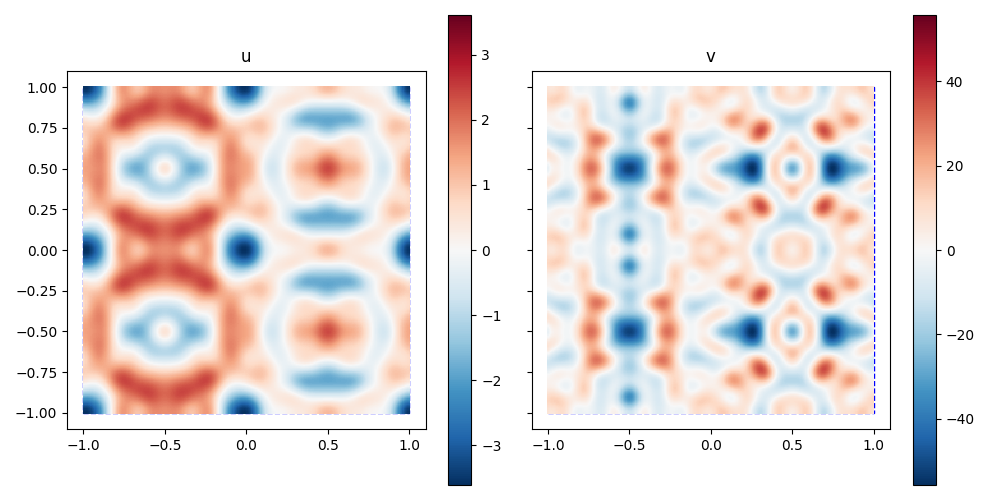

In [7]:
fig, axis, uPlot, vPlot, cPlot, dampPlot = plotState(
    waveSystem.systemState,
    waveSystem.waveState,
    config, config['kernel'],
    markerSize = 0.5,
    plotGrid = True,
    plotCD = False)
# fig.savefig(f'output/{folderName}/initial_state.png', dpi = args.figureDpi)

In [8]:
u = waveSystem.waveState.u
v = waveSystem.waveState.v
c = waveSystem.waveState.c
damp = waveSystem.waveState.damping

# u.requires_grad = True
# v.requires_grad = True

waveSystem.waveState.u = u
waveSystem.waveState.v = v
waveSystem.waveState.c = c
waveSystem.waveState.damping = damp

In [9]:
eulerIntegrator = getIntegrator(IntegrationSchemeType.explicitEuler)
RK4Integrator = getIntegrator(IntegrationSchemeType.rungeKutta4)

In [10]:
waveSystemNext, updates =  eulerIntegrator.function(
    waveSystem,
    dt = dt,
    f = waveSystemFunction,
    verbose = False,
    config = config,
)

In [12]:
# simResultU = waveSystemNext.waveState.u

# print(f'waveSystemNext.waveState.u shape: {simResultU.shape}, dtype: {simResultU.dtype}, device: {simResultU.device}')
# print(f'Value: {simResultU}')

# loss = torch.nn.MSELoss()(simResultU, trajectory[0,:,0])
# print(f'Loss: {loss.item()}')

# loss.backward()

In [13]:
simResultU = waveSystemNext.waveState.u.shape
trajectoryU = trajectory[0,:,0]

print(f'waveSystemNext.waveState.u shape: {simResultU}')
print(f'trajectoryU shape: {trajectoryU.shape}')
print(f'close: {torch.allclose(waveSystemNext.waveState.u.cpu(), trajectory[0,:,0].cpu(), atol=1e-5)}')

waveSystemNext.waveState.u shape: torch.Size([16384])
trajectoryU shape: torch.Size([16384])
close: False


In [14]:
n = waveSystem.waveState.u.shape[0]
nx = int(n**0.5)
print(f'Assuming square grid with nx={nx}, ny={nx}')
domainArea = (config['domain'].max[0] - config['domain'].min[0]) * (config['domain'].max[1] - config['domain'].min[1])
print(f'Particle area: {domainArea/n}, particle spacing: {(domainArea/n)**0.5}')
dx = (domainArea/n)**0.5


Assuming square grid with nx=128, ny=128
Particle area: 0.000244140625, particle spacing: 0.015625


In [17]:
def copyWaveSystem(waveSystem):
    waveStateCopy = WaveEquationState(
        u = waveSystem.waveState.u.clone().detach(),
        v = waveSystem.waveState.v.clone().detach(),
        c = waveSystem.waveState.c.clone().detach(),
        damping = waveSystem.waveState.damping.clone().detach(),
    )
    return WaveSystem(
        systemState = waveSystem.systemState,
        waveState = waveStateCopy,
        neighborhood = waveSystem.neighborhood,
        t = waveSystem.t
    )

waveSystemEuler = copyWaveSystem(waveSystem)
waveSystemRK4 = copyWaveSystem(waveSystem)

for i in range(1):
    waveSystemEuler, updates =  eulerIntegrator.function(
        waveSystemEuler,
        dt = dt,
        f = waveSystemFunction,
        verbose = False,
        config = config,
    )
    waveSystemRK4, updates = RK4Integrator.function(
        waveSystemEuler,
        dt = dt,
        f = waveSystemFunction,
        verbose = False,
        config = config,
    )

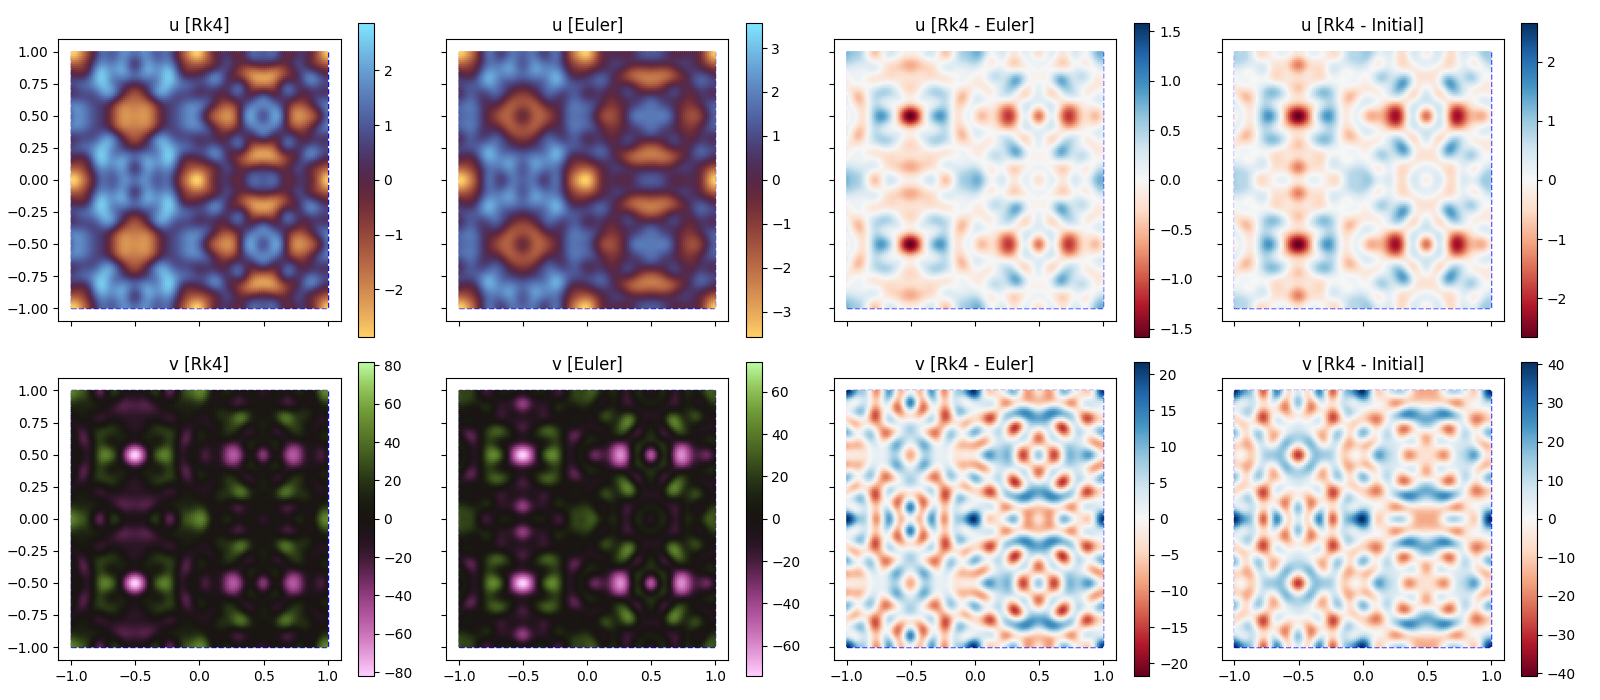

In [18]:
fig, axis = plt.subplots(2, 4, figsize=(16,7), sharex=True, sharey=True)

markerSize = 1.5

uMaxRk4 = torch.max(torch.abs(waveSystemRK4.waveState.u)).cpu().detach().item()
vMaxRk4 = torch.max(torch.abs(waveSystemRK4.waveState.v)).cpu().detach().item()

uPlotRk4 = visualizeParticles(fig, axis[0,0], waveSystem.systemState, config['domain'], waveSystemRK4.waveState.u, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'managua', markerSize = markerSize, gridVisualization = False, title = 'u [Rk4]', vmin = -uMaxRk4, vmax = uMaxRk4)
vPlotRk4 = visualizeParticles(fig, axis[1,0], waveSystem.systemState, config['domain'], waveSystemRK4.waveState.v, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'vanimo', markerSize = markerSize, gridVisualization = False, title = 'v [Rk4]', vmin = -vMaxRk4, vmax = vMaxRk4)


umaxEuler = torch.max(torch.abs(waveSystemEuler.waveState.u)).cpu().detach().item()
vmaxEuler = torch.max(torch.abs(waveSystemEuler.waveState.v)).cpu().detach().item()

uPlotEuler = visualizeParticles(fig, axis[0,1], waveSystem.systemState, config['domain'], waveSystemEuler.waveState.u, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'managua', markerSize = markerSize, gridVisualization = False, title = 'u [Euler]', vmin = -umaxEuler, vmax = umaxEuler)
vPlotEuler = visualizeParticles(fig, axis[1,1], waveSystem.systemState, config['domain'], waveSystemEuler.waveState.v, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'vanimo', markerSize = markerSize, gridVisualization = False, title = 'v [Euler]', vmin = -vmaxEuler, vmax = vmaxEuler)

uDiff = (waveSystemRK4.waveState.u - waveSystemEuler.waveState.u)
vDiff = (waveSystemRK4.waveState.v - waveSystemEuler.waveState.v)

uDiffVmax = torch.max(torch.abs(uDiff)).cpu().detach().item()
vDiffVmax = torch.max(torch.abs(vDiff)).cpu().detach().item()

uPlotDiff = visualizeParticles(fig, axis[0,2], waveSystem.systemState, config['domain'], uDiff, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu', markerSize = markerSize, gridVisualization = False, title = 'u [Rk4 - Euler]', vmin = -uDiffVmax, vmax = uDiffVmax)
vPlotDiff = visualizeParticles(fig, axis[1,2], waveSystem.systemState, config['domain'], vDiff, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu', markerSize = markerSize, gridVisualization = False, title = 'v [Rk4 - Euler]', vmin = -vDiffVmax, vmax = vDiffVmax)

uDiff = (waveSystemRK4.waveState.u - waveSystem.waveState.u)
vDiff = (waveSystemRK4.waveState.v - waveSystem.waveState.v)

uDiffVmax = torch.max(torch.abs(uDiff)).cpu().detach().item()
vDiffVmax = torch.max(torch.abs(vDiff)).cpu().detach().item()

uPlotDiffInitial = visualizeParticles(fig, axis[0,3], waveSystem.systemState, config['domain'], uDiff, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu', markerSize = markerSize, gridVisualization = False, title = 'u [Rk4 - Initial]', vmin = -uDiffVmax, vmax = uDiffVmax)
vPlotDiffInitial = visualizeParticles(fig, axis[1,3], waveSystem.systemState, config['domain'], vDiff, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu', markerSize = markerSize, gridVisualization = False, title = 'v [Rk4 - Initial]', vmin = -vDiffVmax, vmax = vDiffVmax)


fig.tight_layout()